# Disease Prediction Model - Complete Pipeline

In [1]:
# Cell 1: Import Libraries
# ------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Cell 2: Load and Explore Data
# ------------------------------
# Load dataset
df = pd.read_csv('../data/disease_symptom_data.csv')

print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("First 5 rows:")
print(df.head())
print("\n" + "="*50)
print("Disease Distribution:")
print(df['disease'].value_counts())
print("\n" + "="*50)
print("Dataset Info:")
print(df.info())

Dataset Shape: (1200, 42)

First 5 rows:
   bloating  blurred_vision  body_ache  burning_sensation  chest_discomfort  \
0         0               0          0                  0                 0   
1         1               0          0                  0                 0   
2         0               0          0                  0                 0   
3         0               1          0                  0                 0   
4         0               0          0                  0                 0   

   chest_pain  chest_tightness  chills  cloudy_urine  congestion  ...  \
0           0                1       0             0           0  ...   
1           0                0       0             0           0  ...   
2           0                0       1             0           0  ...   
3           0                0       0             0           0  ...   
4           0                0       0             0           0  ...   

   severe_headache  shortness_of_breath  slow

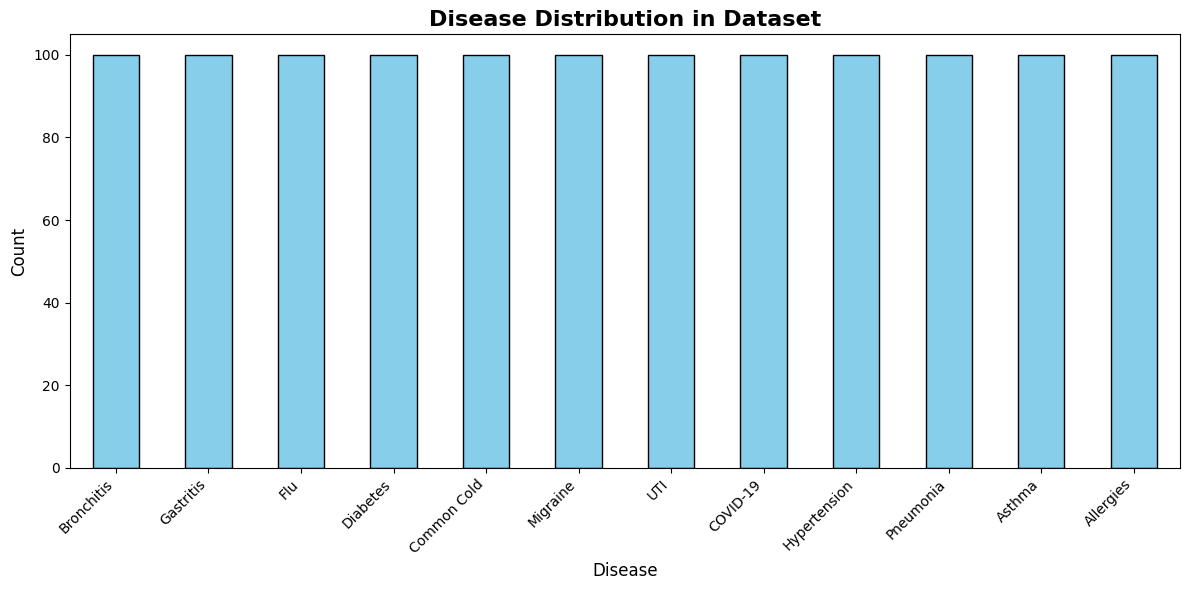

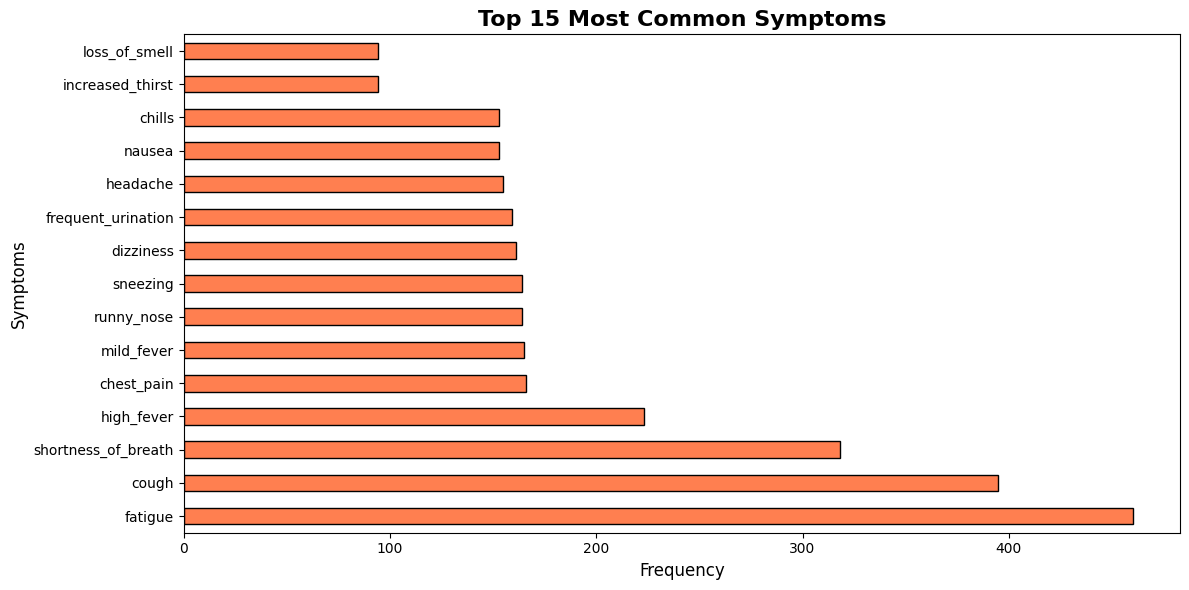

In [4]:
# Cell 3: Data Visualization
# ---------------------------
# Disease distribution
plt.figure(figsize=(12, 6))
df['disease'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Disease Distribution in Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Disease', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Symptom frequency
symptom_cols = [col for col in df.columns if col != 'disease']
symptom_freq = df[symptom_cols].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
symptom_freq.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Top 15 Most Common Symptoms', fontsize=16, fontweight='bold')
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Symptoms', fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
# Cell 4: Data Preparation
# -------------------------
# Separate features and target
X = df.drop('disease', axis=1)
y = df['disease']

# Get symptom names
symptom_names = X.columns.tolist()

print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of unique diseases: {y.nunique()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Number of features: 41
Number of samples: 1200
Number of unique diseases: 12

Training set size: 960
Testing set size: 240


In [6]:
# Cell 5: Train Random Forest Model
# ----------------------------------
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Model trained successfully!")

# Predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Evaluate
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

# Cross-validation
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)
print(f"Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Training Random Forest Classifier...
Model trained successfully!

Training Accuracy: 0.9958
Testing Accuracy: 0.9958
Cross-Validation Accuracy: 0.9885 (+/- 0.0077)


Classification Report:
              precision    recall  f1-score   support

   Allergies       1.00      1.00      1.00        20
      Asthma       1.00      1.00      1.00        20
  Bronchitis       1.00      1.00      1.00        20
    COVID-19       1.00      1.00      1.00        20
 Common Cold       1.00      1.00      1.00        20
    Diabetes       1.00      1.00      1.00        20
         Flu       0.95      1.00      0.98        20
   Gastritis       1.00      1.00      1.00        20
Hypertension       1.00      1.00      1.00        20
    Migraine       1.00      1.00      1.00        20
   Pneumonia       1.00      0.95      0.97        20
         UTI       1.00      1.00      1.00        20

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



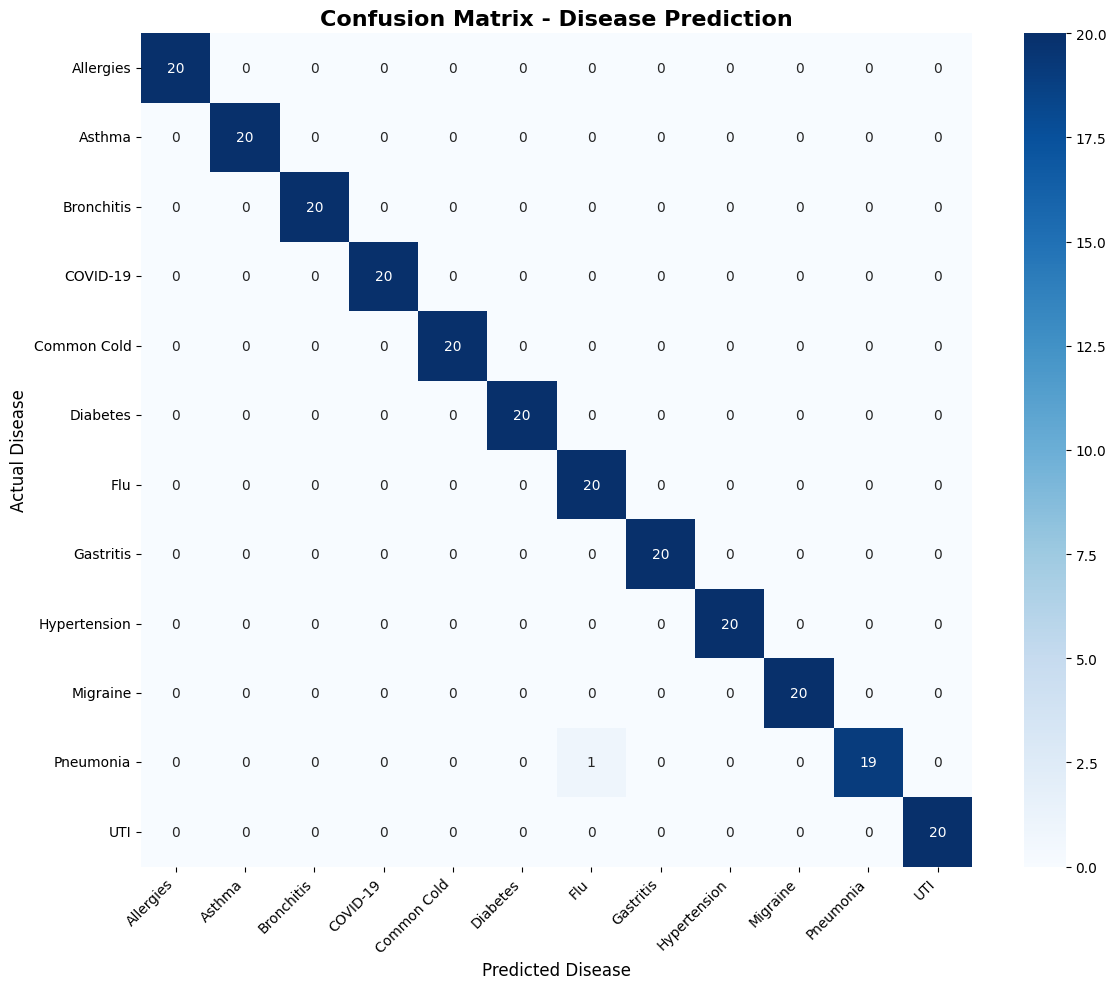

In [7]:
# Cell 6: Detailed Evaluation
# ----------------------------
print("Classification Report:")
print("="*70)
print(classification_report(y_test, y_pred_test))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_)
plt.title('Confusion Matrix - Disease Prediction', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Disease', fontsize=12)
plt.ylabel('Actual Disease', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Top 20 Most Important Symptoms:
                 symptom  importance
28             nosebleed    0.045581
31  sensitivity_to_light    0.043551
4       chest_discomfort    0.041027
5             chest_pain    0.040488
19      increased_thirst    0.039883
25            mild_fever    0.034276
13             dry_cough    0.032643
30            runny_nose    0.031371
36           sore_throat    0.029805
38        vision_changes    0.028426
11  difficulty_breathing    0.028387
0               bloating    0.028190
7                 chills    0.027229
17              headache    0.026835
2              body_ache    0.026660
39              vomiting    0.026041
6        chest_tightness    0.025935
29                  rash    0.024803
3      burning_sensation    0.024025
8           cloudy_urine    0.023481


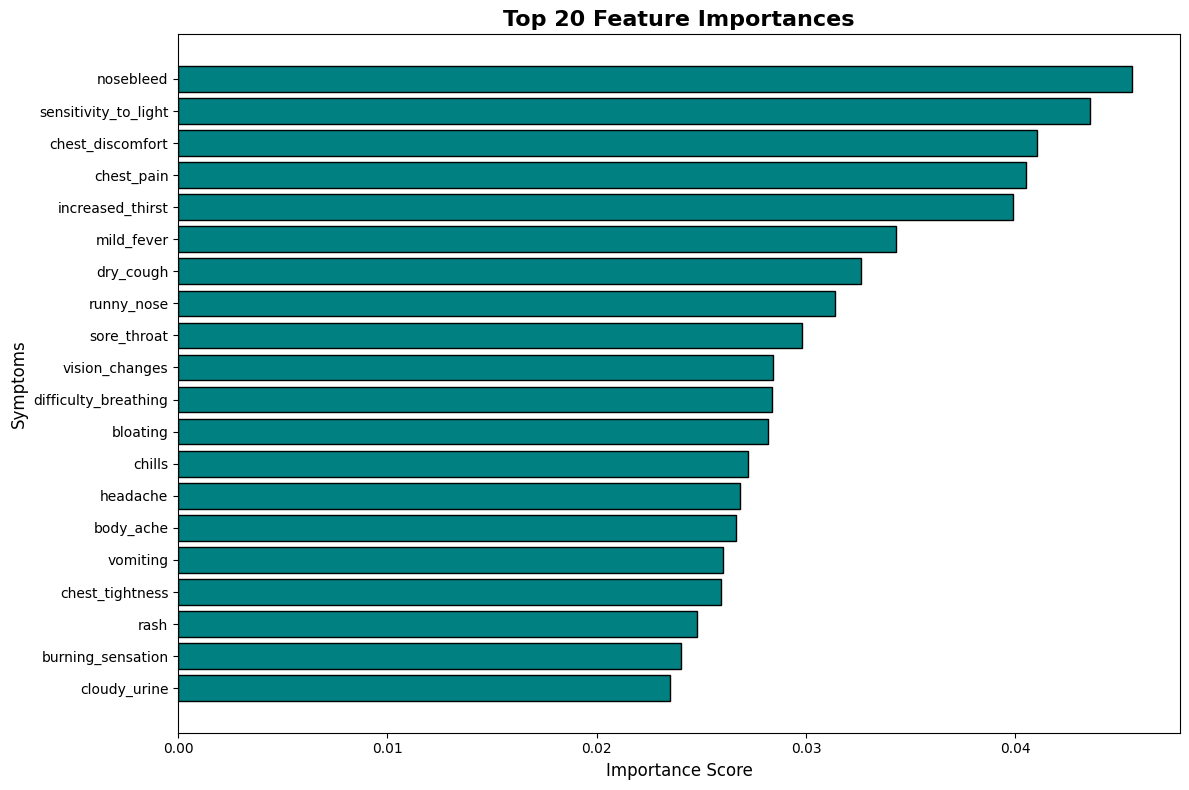

In [8]:
# Cell 7: Feature Importance Analysis
# ------------------------------------
# Get feature importance
feature_importance = pd.DataFrame({
    'symptom': symptom_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important Symptoms:")
print(feature_importance.head(20))

# Visualize
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'], color='teal', edgecolor='black')
plt.yticks(range(len(top_features)), top_features['symptom'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Symptoms', fontsize=12)
plt.title('Top 20 Feature Importances', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [9]:
# Cell 8: Save Model and Artifacts
# ---------------------------------
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the model
model_path = '../models/disease_prediction_model.pkl'
joblib.dump(rf_model, model_path)
print(f"Model saved to: {model_path}")

# Save symptom names
symptom_path = '../models/symptom_names.pkl'
joblib.dump(symptom_names, symptom_path)
print(f"Symptom names saved to: {symptom_path}")

# Save feature importance
feature_importance_path = '../models/feature_importance.pkl'
joblib.dump(feature_importance, feature_importance_path)
print(f"Feature importance saved to: {feature_importance_path}")

# Save disease list
disease_list = rf_model.classes_.tolist()
disease_path = '../models/disease_list.pkl'
joblib.dump(disease_list, disease_path)
print(f"Disease list saved to: {disease_path}")

print("\n" + "="*70)
print("All artifacts saved successfully!")
print("="*70)

Model saved to: ../models/disease_prediction_model.pkl
Symptom names saved to: ../models/symptom_names.pkl
Feature importance saved to: ../models/feature_importance.pkl
Disease list saved to: ../models/disease_list.pkl

All artifacts saved successfully!


In [10]:
# Cell 9: Test Prediction Function
# ---------------------------------
def predict_disease(symptoms_input, model, symptom_names):
    """
    Predict disease based on input symptoms
    
    Parameters:
    -----------
    symptoms_input : list
        List of symptom names
    model : trained model
        Disease prediction model
    symptom_names : list
        List of all possible symptom names
    
    Returns:
    --------
    predictions : list of tuples
        Top 3 predictions with probabilities
    """
    # Create feature vector
    features = np.zeros(len(symptom_names))
    for symptom in symptoms_input:
        if symptom in symptom_names:
            idx = symptom_names.index(symptom)
            features[idx] = 1
    
    # Reshape for prediction
    features = features.reshape(1, -1)
    
    # Get predictions
    prediction = model.predict(features)[0]
    probabilities = model.predict_proba(features)[0]
    
    # Get top 3 predictions
    top_3_idx = np.argsort(probabilities)[-3:][::-1]
    top_3_diseases = model.classes_[top_3_idx]
    top_3_probs = probabilities[top_3_idx]
    
    results = [(disease, prob) for disease, prob in zip(top_3_diseases, top_3_probs)]
    
    return results

# Test the function
test_symptoms = ['high_fever', 'cough', 'fatigue', 'shortness_of_breath']
print(f"\nTest Symptoms: {test_symptoms}")
print("\nPredictions:")
predictions = predict_disease(test_symptoms, rf_model, symptom_names)
for i, (disease, prob) in enumerate(predictions, 1):
    print(f"{i}. {disease}: {prob:.2%}")

print("\n" + "="*70)
print("Model training and evaluation complete!")
print("="*70)


Test Symptoms: ['high_fever', 'cough', 'fatigue', 'shortness_of_breath']

Predictions:
1. Pneumonia: 40.00%
2. Flu: 18.07%
3. Asthma: 11.16%

Model training and evaluation complete!
